In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.set_option("display.max_columns", 200)

df = pd.read_csv("heart_disease_uci.csv")

print("Shape :", df.shape)
display(df.head())


Shape : (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [39]:
# 2.1 Types de variables & statistiques descriptives
print("=" * 60)
print("TYPES DE VARIABLES")
print("=" * 60)
display(df.dtypes)

print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
display(df.describe(include='all').T)


TYPES DE VARIABLES


id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


STATISTIQUES DESCRIPTIVES


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [40]:
# 2.2 Valeurs manquantes
print("=" * 60)
print("VALEURS MANQUANTES")
print("=" * 60)
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Nb manquants": missing, "Pourcentage %": missing_pct})
display(missing_df[missing_df["Nb manquants"] > 0])
print("\nTotal valeurs manquantes :", int(missing.sum()))


VALEURS MANQUANTES


,Nb manquants,Pourcentage %
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
exang,55,5.98
thalch,55,5.98
chol,30,3.26
restecg,2,0.22



Total valeurs manquantes : 1759


In [41]:
# 2.3 Doublons
print("=" * 60)
print("DOUBLONS")
print("=" * 60)
n_dup = df.duplicated().sum()
print("Nombre de doublons :", n_dup)


DOUBLONS
Nombre de doublons : 0


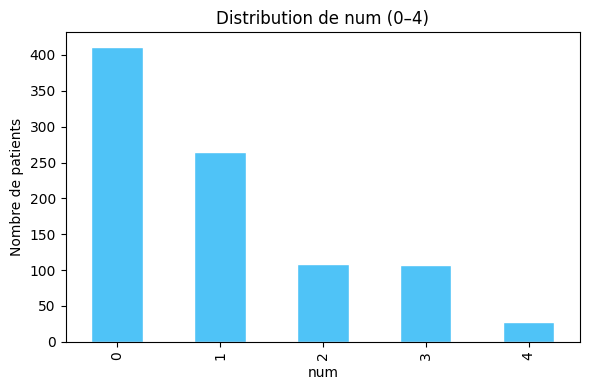

In [42]:
# 2.4 Distribution de la cible brute `num` (0–4)
plt.figure(figsize=(6, 4))
df["num"].value_counts().sort_index().plot(kind="bar", edgecolor="white", color="#4FC3F7")
plt.title("Distribution de num (0–4)")
plt.xlabel("num")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()


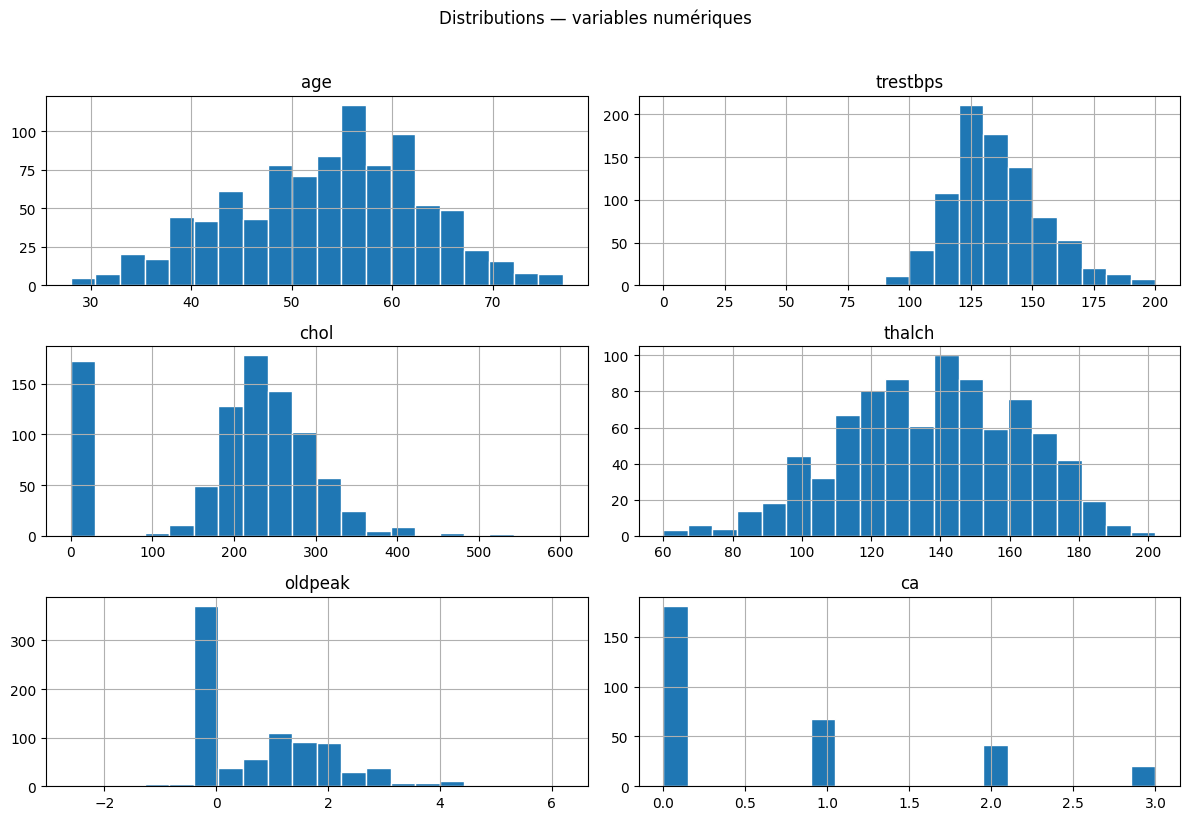

In [43]:
# 2.5 Distributions des variables numériques
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
num_cols = [c for c in num_cols if c in df.columns]

df[num_cols].hist(bins=20, figsize=(12, 8), edgecolor="white")
plt.suptitle("Distributions — variables numériques", y=1.02)
plt.tight_layout()
plt.show()


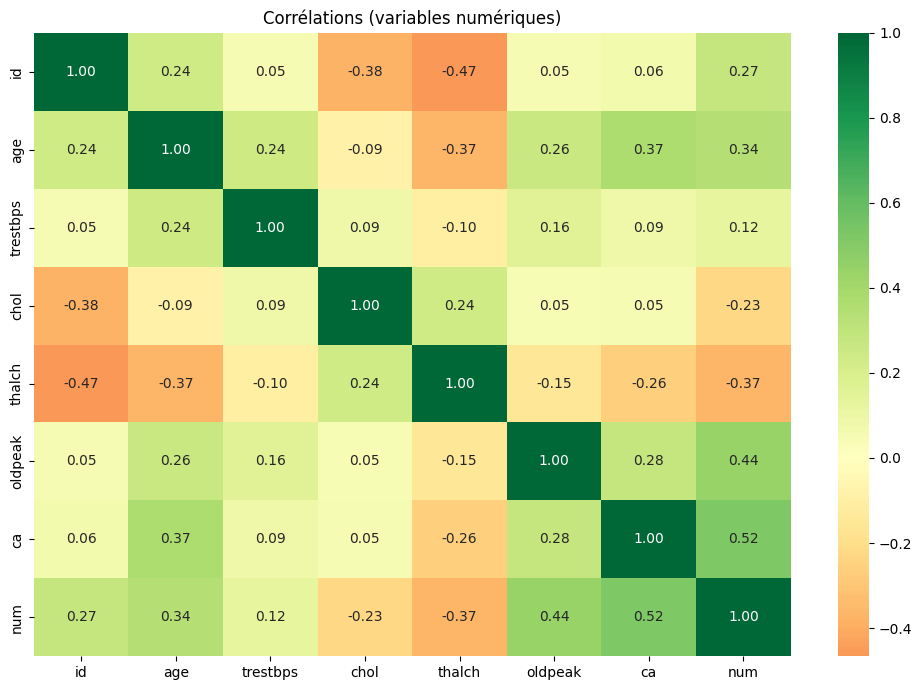

In [44]:
# 2.6 Heatmap de corrélation (variables numériques)
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include=["number"]).corr(),
            annot=True, cmap="RdYlGn", center=0, fmt=".2f")
plt.title("Corrélations (variables numériques)")
plt.tight_layout()
plt.show()


In [45]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 3.1 Copie de travail + supprimer l'identifiant
data = df.copy()
if "id" in data.columns:
    data = data.drop(columns=["id"])
if "dataset" in data.columns:
    data = data.drop(columns=["dataset"])

# 3.2 Créer la cible binaire (0 = sain, 1 = malade)
data["target"] = (data["num"] > 0).astype(int)
data = data.drop(columns=["num"])

# 3.3 Convertir fbs / exang (True/False → 0/1)
# FIX: map both bool objects and 'True'/'False' strings robustly
data["fbs"]   = data["fbs"].map({True: 1, False: 0, "True": 1, "False": 0})
data["exang"] = data["exang"].map({True: 1, False: 0, "True": 1, "False": 0})

print("Shape après nettoyage :", data.shape)
print("\nDistribution de la cible :")
print(data["target"].value_counts())
display(data.head())


Shape après nettoyage : (920, 14)

Distribution de la cible :
target
1    509
0    411
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0.0,normal,0


Data Preparation

In [46]:
# 3.4 Imputation des valeurs manquantes
clean = data.copy()

num_cols = clean.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in clean.columns if c not in num_cols]

for c in num_cols:
    clean[c] = clean[c].fillna(clean[c].median())

for c in cat_cols:
    if c != "target":
        clean[c] = clean[c].fillna(clean[c].mode(dropna=True)[0])

print("✅ NaN après imputation :", int(clean.isnull().sum().sum()))


✅ NaN après imputation : 0


In [47]:
# 3.5 Encodage One-Hot pour les variables catégorielles
cat_to_ohe = [c for c in cat_cols if c not in ["target"]]
encoded = pd.get_dummies(clean, columns=cat_to_ohe, drop_first=False)

print("Colonnes avant OHE :", clean.shape[1])
print("Colonnes après OHE :", encoded.shape[1])
display(encoded.head())


Colonnes avant OHE : 14
Colonnes après OHE : 24


,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,63,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,False,True,False,False,False,True,True,False,False,True,False,False,True,False,False
1,67,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,False,True,True,False,False,False,True,False,False,False,True,False,False,True,False
2,67,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,False,True,True,False,False,False,True,False,False,False,True,False,False,False,True
3,37,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False
4,41,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,True,False,False,True,False,False,True,False,False,False,False,True,False,True,False


In [48]:
from sklearn.preprocessing import MinMaxScaler

scaled = encoded.copy()

# 3.6 Normalisation MinMaxScaler (hors target)
num_to_scale = [c for c in scaled.columns if scaled[c].dtype != "uint8" and c != "target"]
scaler = MinMaxScaler()
scaled[num_to_scale] = scaler.fit_transform(scaled[num_to_scale])

print("✅ Vérification min/max ~ [0,1] :")
display(scaled[num_to_scale].agg(["min", "max"]).T.head(10))


✅ Vérification min/max ~ [0,1] :


,min,max
age,0.0,1.0
trestbps,0.0,1.0
chol,0.0,1.0
fbs,0.0,1.0
thalch,0.0,1.0
exang,0.0,1.0
oldpeak,0.0,1.0
ca,0.0,1.0
sex_Female,0.0,1.0
sex_Male,0.0,1.0


Top corrélations (|r|) avec target


cp_asymptomatic           0.515736
exang                     0.433605
cp_atypical angina       -0.403465
thalch                   -0.381864
oldpeak                   0.366138
sex_Female               -0.307284
sex_Male                  0.307284
thal_normal              -0.286196
age                       0.282700
thal_reversable defect    0.257029
chol                     -0.228976
cp_non-anginal           -0.209812
slope_upsloping          -0.180903
ca                        0.164755
slope_downsloping         0.122444
Name: target, dtype: float64

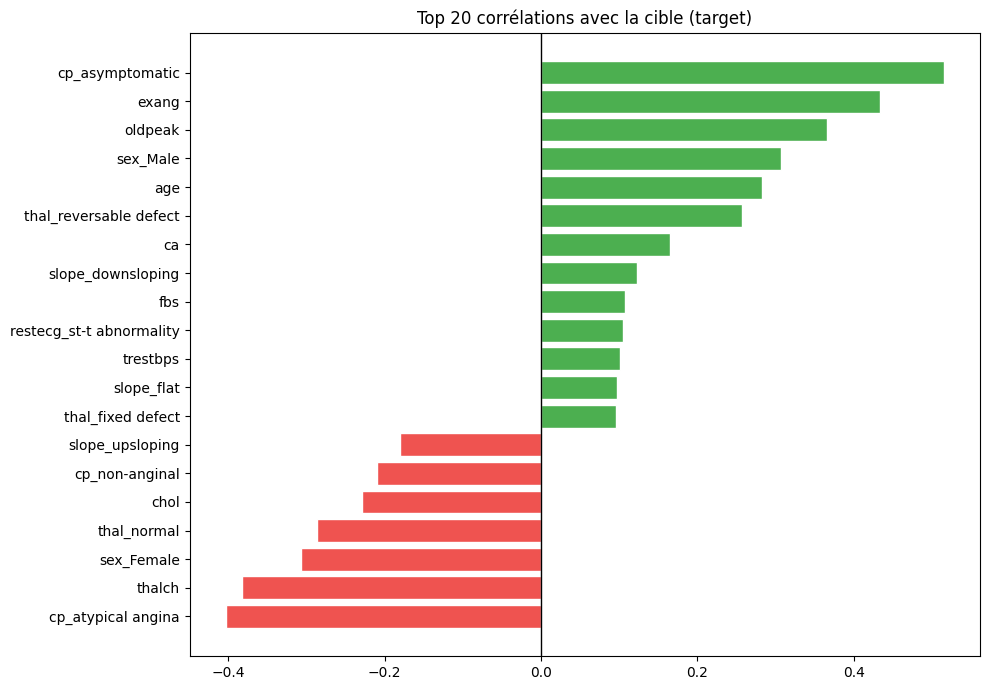

In [49]:
# 3.7 Analyse des corrélations avec la cible
target_corr = scaled.corr(numeric_only=True)["target"].drop("target")
target_corr_sorted = target_corr.reindex(
    target_corr.abs().sort_values(ascending=False).index)

print("=" * 70)
print("Top corrélations (|r|) avec target")
print("=" * 70)
display(target_corr_sorted.head(15))

plt.figure(figsize=(10, 7))
vals = target_corr_sorted.head(20).sort_values()
colors = ["#EF5350" if v < 0 else "#4CAF50" for v in vals.values]
plt.barh(vals.index, vals.values, color=colors, edgecolor="white")
plt.axvline(0, color="black", lw=1)
plt.title("Top 20 corrélations avec la cible (target)")
plt.tight_layout()
plt.show()


In [50]:
# 3.8 Détection de multicolinéarité (|r| > 0.9)
top_feats = target_corr_sorted.head(25).index.tolist()
corr_mat = scaled[top_feats].corr()

pairs = []
cols = corr_mat.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.9:
            pairs.append((cols[i], cols[j], round(r, 3)))

print("Paires très corrélées (|r| > 0.9) :", len(pairs))
if pairs:
    display(pd.DataFrame(pairs, columns=["Feature 1", "Feature 2", "r"])
            .sort_values("r", key=lambda s: s.abs(), ascending=False))
else:
    print("Aucune paire avec |r| > 0.9 trouvée.")


Paires très corrélées (|r| > 0.9) : 1


,Feature 1,Feature 2,r
0,sex_Female,sex_Male,-1.0


In [51]:
# 3.9 Sélection finale des features (seuil |r| >= 0.30)
features_selected = target_corr_sorted[abs(target_corr_sorted) >= 0.30].index.tolist()

print("Nb features sélectionnées :", len(features_selected))
print(features_selected)

X_final = scaled[features_selected].copy()
y_final = scaled["target"].copy()
display(X_final.head())


Nb features sélectionnées : 7
['cp_asymptomatic', 'exang', 'cp_atypical angina', 'thalch', 'oldpeak', 'sex_Female', 'sex_Male']


,cp_asymptomatic,exang,cp_atypical angina,thalch,oldpeak,sex_Female,sex_Male
0,0.0,0.0,0.0,0.633803,0.556818,0.0,1.0
1,1.0,1.0,0.0,0.338028,0.465909,0.0,1.0
2,1.0,1.0,0.0,0.485915,0.590909,0.0,1.0
3,0.0,0.0,0.0,0.894366,0.693182,0.0,1.0
4,0.0,0.0,1.0,0.788732,0.454545,1.0,0.0


In [52]:
# 3.9 Sélection finale des features (seuil |r| >= 0.30)
features_selected = target_corr_sorted[abs(target_corr_sorted) >= 0.30].index.tolist()

print("Nb features sélectionnées :", len(features_selected))
print(features_selected)

X_final = scaled[features_selected].copy()
y_final = scaled["target"].copy()
display(X_final.head())


Nb features sélectionnées : 7
['cp_asymptomatic', 'exang', 'cp_atypical angina', 'thalch', 'oldpeak', 'sex_Female', 'sex_Male']


,cp_asymptomatic,exang,cp_atypical angina,thalch,oldpeak,sex_Female,sex_Male
0,0.0,0.0,0.0,0.633803,0.556818,0.0,1.0
1,1.0,1.0,0.0,0.338028,0.465909,0.0,1.0
2,1.0,1.0,0.0,0.485915,0.590909,0.0,1.0
3,0.0,0.0,0.0,0.894366,0.693182,0.0,1.0
4,0.0,0.0,1.0,0.788732,0.454545,1.0,0.0


# 4. Modeling

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Repartir de `data` (avant OHE) pour les pipelines sklearn
raw = data.copy()

X = raw.drop(columns=["target"])
y = raw["target"]

# Split stratifié : 60% train / 20% validation / 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Colonnes numériques / catégorielles
numeric_features = ["age", "trestbps", "chol", "thalch",
                    "oldpeak", "ca", "fbs", "exang"]
numeric_features = [c for c in numeric_features if c in X.columns]
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("✅ Pipeline preprocessing prête.")
print(f"Train : {X_train.shape[0]}  |  Validation : {X_val.shape[0]}  |  Test : {X_test.shape[0]}")


✅ Pipeline preprocessing prête.
Train : 552  |  Validation : 184  |  Test : 184


Nb features après preprocessing : 23
Nb composantes PCA (95% variance) : 14
Variance expliquée totale : 0.966


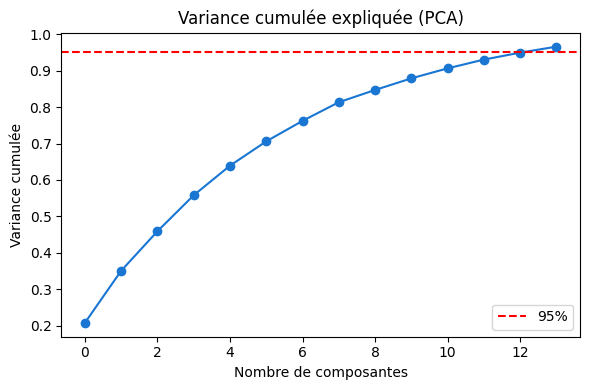

In [54]:
# 4.1 ACP — réduction dimensionnelle (95% variance)
Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)

pca95 = PCA(n_components=0.95, random_state=42)
Xtr_pca = pca95.fit_transform(Xtr)

print("Nb features après preprocessing :", Xtr.shape[1])
print("Nb composantes PCA (95% variance) :", pca95.n_components_)
print("Variance expliquée totale :", round(pca95.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca95.explained_variance_ratio_), marker="o", color="#1976D2")
plt.axhline(0.95, linestyle="--", color="red", label="95%")
plt.title("Variance cumulée expliquée (PCA)")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.legend()
plt.tight_layout()
plt.show()


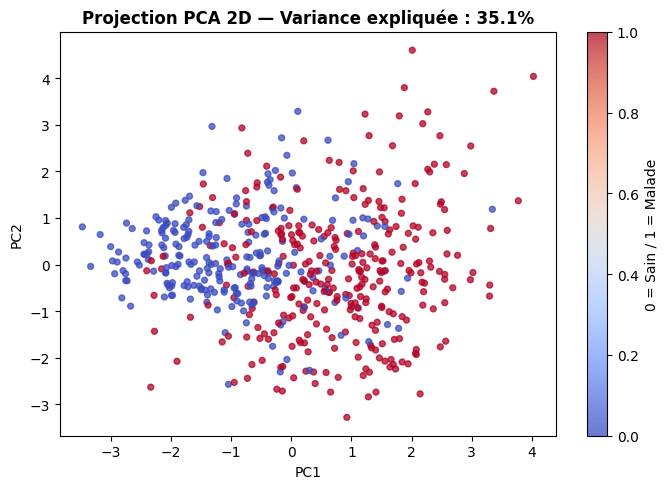

In [55]:
# 4.2 ACP 2D — visualisation
pca2 = PCA(n_components=2, random_state=42)
Xtr_2d = pca2.fit_transform(Xtr)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(Xtr_2d[:, 0], Xtr_2d[:, 1],
                      c=y_train, cmap="coolwarm", s=18, alpha=0.75)
plt.colorbar(scatter, label="0 = Sain / 1 = Malade")
plt.title(f"Projection PCA 2D — Variance expliquée : "
          f"{pca2.explained_variance_ratio_.sum()*100:.1f}%", fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


,k,silhouette
1,3,0.387154
0,2,0.382149
3,5,0.342334
2,4,0.341718


✅ k choisi (max silhouette) : 3


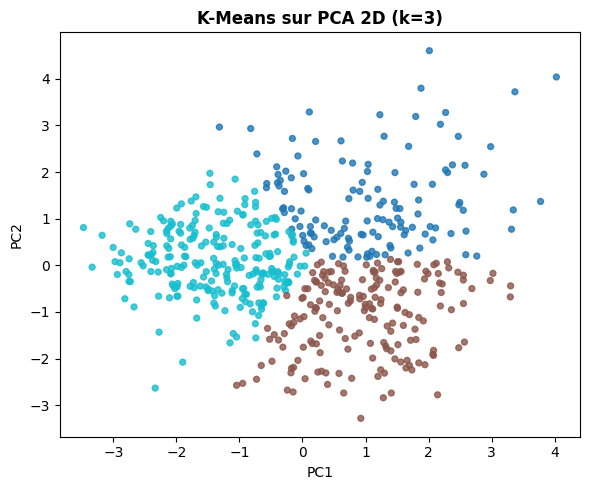

ARI (clusters vs target) : 0.253


In [56]:
from threadpoolctl import threadpool_limits

# 4.3 K-Means — sélection du meilleur k (silhouette)
sil_scores = []
with threadpool_limits(limits=1):
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=42, n_init=3, algorithm="lloyd")
        labels = km.fit_predict(Xtr_2d)
        sil = silhouette_score(Xtr_2d, labels)
        sil_scores.append((k, sil))

sil_df = pd.DataFrame(sil_scores, columns=["k", "silhouette"]).sort_values("silhouette", ascending=False)
display(sil_df)

best_k = int(sil_df.iloc[0]["k"])
print("✅ k choisi (max silhouette) :", best_k)

with threadpool_limits(limits=1):
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=5, algorithm="lloyd")
    km_labels = kmeans.fit_predict(Xtr_2d)

plt.figure(figsize=(6, 5))
plt.scatter(Xtr_2d[:, 0], Xtr_2d[:, 1], c=km_labels, s=18, alpha=0.8, cmap="tab10")
plt.title(f"K-Means sur PCA 2D (k={best_k})", fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print("ARI (clusters vs target) :", round(adjusted_rand_score(y_train, km_labels), 3))


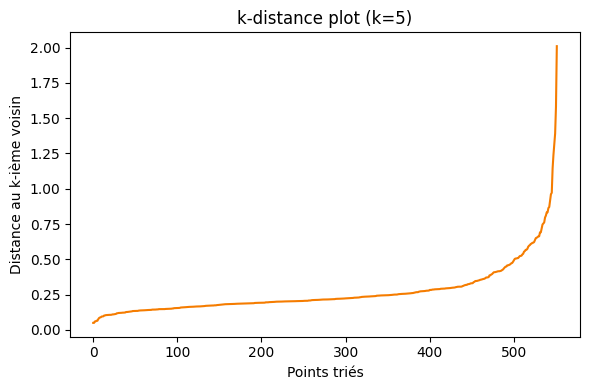

eps candidats (percentiles 80/85/90/95) : [0.315 0.372 0.467 0.62 ]


In [57]:
# 4.4 DBSCAN — choix de eps via k-distance plot
min_samples = 5

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(Xtr_2d)
dists, _ = nn.kneighbors(Xtr_2d)
kdist = np.sort(dists[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(kdist, color="#F57C00")
plt.title(f"k-distance plot (k={min_samples})")
plt.xlabel("Points triés")
plt.ylabel("Distance au k-ième voisin")
plt.tight_layout()
plt.show()

eps_candidates = np.percentile(kdist, [80, 85, 90, 95])
print("eps candidats (percentiles 80/85/90/95) :", np.round(eps_candidates, 3))


In [58]:
# 4.5 DBSCAN — évaluation de plusieurs eps
def eval_dbscan(eps, min_samples=5):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(Xtr_2d)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).mean()
    sil = None
    mask = labels != -1
    if n_clusters >= 2 and mask.sum() > 10:
        sil = float(silhouette_score(Xtr_2d[mask], labels[mask]))
    ari = float(adjusted_rand_score(y_train, labels))
    return n_clusters, noise, sil, ari

tests = []
for eps_val in [0.25, 0.30, 0.35, 0.40, 0.45]:
    ncl, noise, sil, ari = eval_dbscan(eps_val, min_samples=min_samples)
    tests.append((eps_val, ncl, noise, sil, ari))

dbscan_df = pd.DataFrame(tests, columns=["eps", "n_clusters",
                                          "noise_ratio", "silhouette", "ARI_vs_target"])
display(dbscan_df)


,eps,n_clusters,noise_ratio,silhouette,ARI_vs_target
0,0.25,13,0.211957,-0.117293,0.030712
1,0.30,4,0.152174,0.030148,0.002549
2,0.35,2,0.115942,0.351918,-0.008512
3,0.40,2,0.088768,0.350396,-0.009572
4,0.45,1,0.061594,NaN,-0.007910


Eps retenu : 0.35


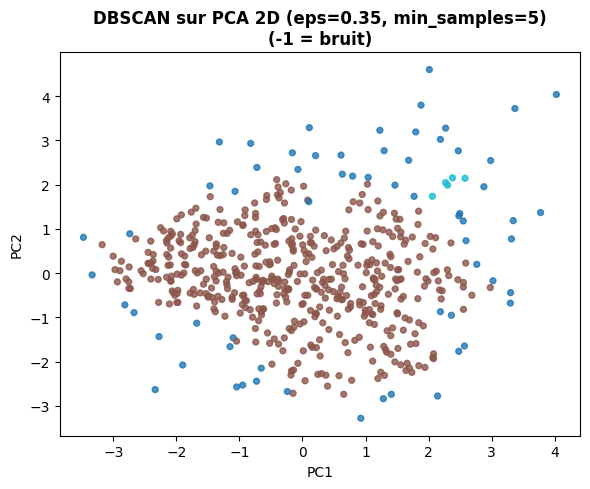

Nb clusters : 2
Bruit (ratio) : 0.116
ARI (clusters vs target) : -0.009


In [59]:
# 4.6 DBSCAN — visualisation avec le meilleur eps
valid = dbscan_df[dbscan_df["n_clusters"] >= 2].dropna(subset=["silhouette"])
if not valid.empty:
    best_eps = float(valid.loc[valid["silhouette"].idxmax(), "eps"])
else:
    best_eps = 0.35
print(f"Eps retenu : {best_eps}")

dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(Xtr_2d)

plt.figure(figsize=(6, 5))
plt.scatter(Xtr_2d[:, 0], Xtr_2d[:, 1], c=db_labels, s=18, alpha=0.8, cmap="tab10")
plt.title(f"DBSCAN sur PCA 2D (eps={best_eps}, min_samples={min_samples})\n(-1 = bruit)",
          fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

print("Nb clusters :", len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Bruit (ratio) :", round((db_labels == -1).mean(), 3))
print("ARI (clusters vs target) :", round(adjusted_rand_score(y_train, db_labels), 3))


# 5. Evaluation

In [60]:
!pip install xgboost imbalanced-learn -q

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, mean_squared_error)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, plot_importance


In [62]:
# 5.1 SMOTE — appliqué UNIQUEMENT sur le train (pas de fuite de données)
# FIX: SMOTE must be fit only on X_train to avoid data leakage into test/val.
print("=== Distribution initiale ===")
print("y_train :", Counter(y_train))
print("y_val   :", Counter(y_val))
print("y_test  :", Counter(y_test))

X_train_prep = preprocess.fit_transform(X_train)
X_val_prep   = preprocess.transform(X_val)
X_test_prep  = preprocess.transform(X_test)

smote = SMOTE(random_state=42)
X_train_s, y_train_s = smote.fit_resample(X_train_prep, y_train)

X_val_s,  y_val_s  = X_val_prep,  y_val.copy()
X_test_s, y_test_s = X_test_prep, y_test.copy()

print("\n=== Après SMOTE (train seulement) ===")
print("y_train_s :", Counter(y_train_s))
print("y_val_s   :", Counter(y_val_s))
print("y_test_s  :", Counter(y_test_s))
print(f"\nTrain : {X_train_s.shape[0]}  |  Val : {X_val_s.shape[0]}  |  Test : {X_test_s.shape[0]}")


=== Distribution initiale ===
y_train : Counter({1: 305, 0: 247})
y_val   : Counter({1: 102, 0: 82})
y_test  : Counter({1: 102, 0: 82})

=== Après SMOTE (train seulement) ===
y_train_s : Counter({0: 305, 1: 305})
y_val_s   : Counter({1: 102, 0: 82})
y_test_s  : Counter({1: 102, 0: 82})

Train : 610  |  Val : 184  |  Test : 184


In [63]:
# 5.2 Fonction d'évaluation unifiée
# FIX: single definition — confusion matrix + full report
resultats = []

def evaluer(nom_modele, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n=== {nom_modele} ===")
    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {prec:.3f}")
    print(f"Recall    : {rec:.3f}")
    print(f"F1-Score  : {f1:.3f}")
    print("\nRapport de classification :")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sain", "Malade"])
    disp.plot(cmap="Blues")
    plt.title(f"Matrice de confusion — {nom_modele}")
    plt.show()

    return {"Modèle": nom_modele, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}



=== SVM ===
Accuracy  : 0.810
Precision : 0.813
Recall    : 0.810
F1-Score  : 0.810

Rapport de classification :
              precision    recall  f1-score   support

           0       0.76      0.83      0.80        82
           1       0.85      0.79      0.82       102

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.81      0.81      0.81       184



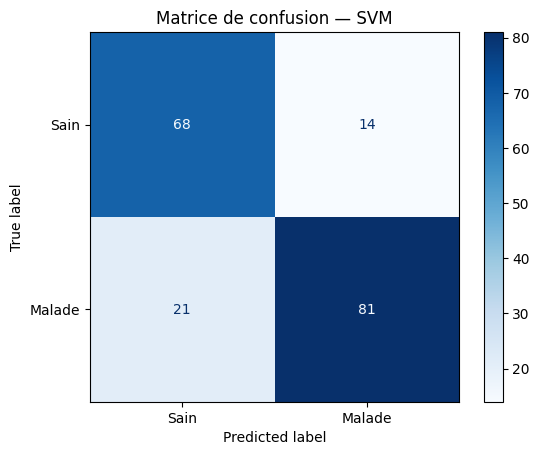

In [64]:
# 5.3 SVM
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_train_s, y_train_s)
resultats.append(evaluer("SVM", y_test_s, svm.predict(X_test_s)))



=== KNN ===
Accuracy  : 0.788
Precision : 0.797
Recall    : 0.788
F1-Score  : 0.789

Rapport de classification :
              precision    recall  f1-score   support

           0       0.73      0.84      0.78        82
           1       0.85      0.75      0.80       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184



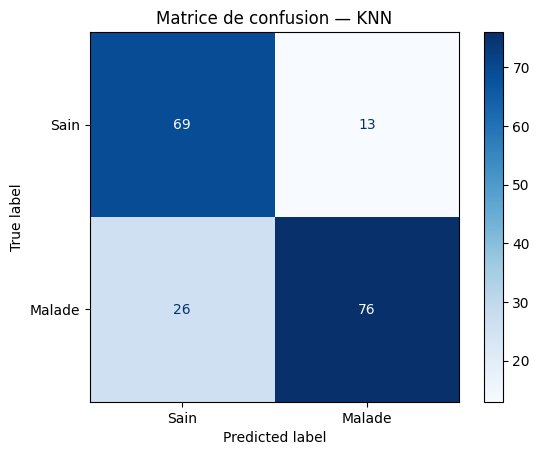

In [65]:
# 5.4 KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_s, y_train_s)
resultats.append(evaluer("KNN", y_test_s, knn.predict(X_test_s)))



=== Arbre de décision ===
Accuracy  : 0.783
Precision : 0.795
Recall    : 0.783
F1-Score  : 0.783

Rapport de classification :
              precision    recall  f1-score   support

           0       0.71      0.85      0.78        82
           1       0.86      0.73      0.79       102

    accuracy                           0.78       184
   macro avg       0.79      0.79      0.78       184
weighted avg       0.80      0.78      0.78       184



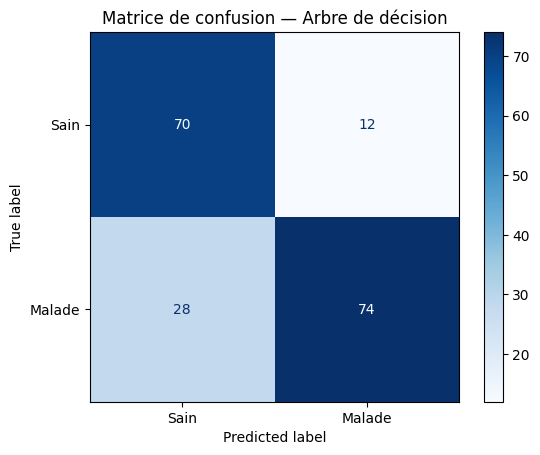

In [66]:
# 5.5 Arbre de décision
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train_s, y_train_s)
resultats.append(evaluer("Arbre de décision", y_test_s, dt.predict(X_test_s)))



=== KNN ===
Accuracy  : 0.788
Precision : 0.797
Recall    : 0.788
F1-Score  : 0.789

Rapport de classification :
              precision    recall  f1-score   support

           0       0.73      0.84      0.78        82
           1       0.85      0.75      0.80       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.80      0.79      0.79       184



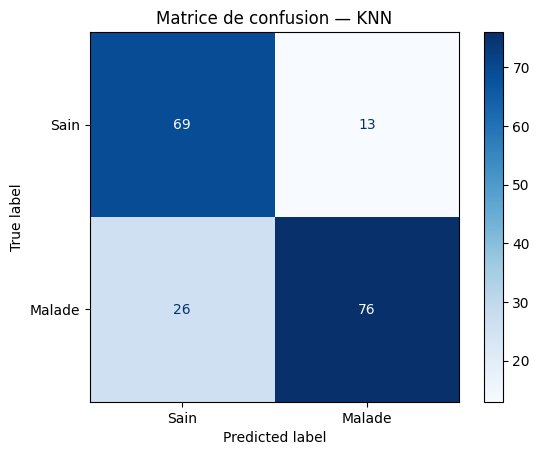

In [67]:
# 5.2 KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_s, y_train_s)
resultats.append(evaluer("KNN", y_test_s, knn.predict(X_test_s)))



=== Régression logistique ===
Accuracy  : 0.799
Precision : 0.806
Recall    : 0.799
F1-Score  : 0.800

Rapport de classification :
              precision    recall  f1-score   support

           0       0.74      0.84      0.79        82
           1       0.86      0.76      0.81       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.81      0.80      0.80       184



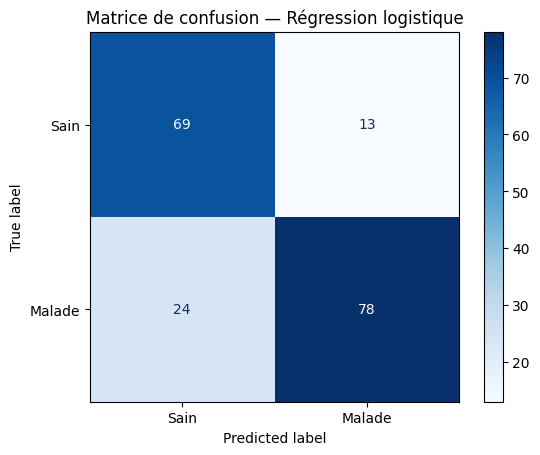

In [68]:
# 5.6 Régression logistique
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_s, y_train_s)
resultats.append(evaluer("Régression logistique", y_test_s, lr.predict(X_test_s)))



=== Régression linéaire (seuil 0.5) ===
Accuracy  : 0.815
Precision : 0.819
Recall    : 0.815
F1-Score  : 0.816

Rapport de classification :
              precision    recall  f1-score   support

           0       0.77      0.84      0.80        82
           1       0.86      0.79      0.83       102

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.81       184
weighted avg       0.82      0.82      0.82       184



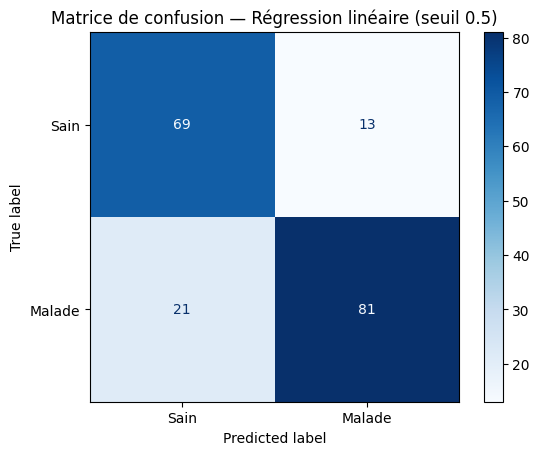

In [69]:
# 5.7 Régression linéaire (seuil 0.5) — baseline
lr_lin = LinearRegression()
lr_lin.fit(X_train_s, y_train_s)
y_pred_lin = (np.clip(lr_lin.predict(X_test_s), 0, 1) >= 0.5).astype(int)
resultats.append(evaluer("Régression linéaire (seuil 0.5)", y_test_s, y_pred_lin))



=== XGBoost ===
Accuracy  : 0.804
Precision : 0.809
Recall    : 0.804
F1-Score  : 0.805

Rapport de classification :
              precision    recall  f1-score   support

           0       0.76      0.83      0.79        82
           1       0.85      0.78      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.80       184



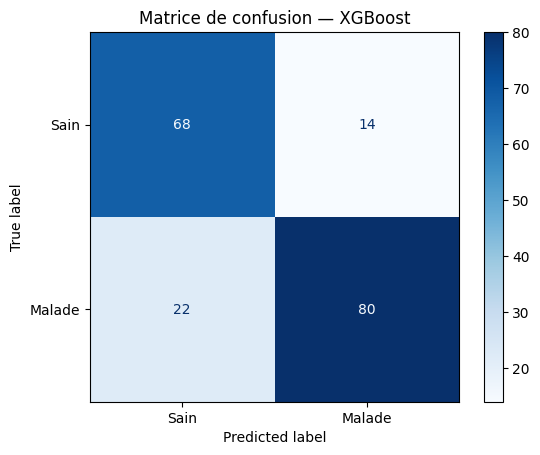

In [70]:
# 5.8 XGBoost
# FIX: removed deprecated use_label_encoder parameter
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_s, y_train_s,
        eval_set=[(X_val_s, y_val_s)],
        verbose=False)
resultats.append(evaluer("XGBoost", y_test_s, xgb.predict(X_test_s)))



=== COMPARAISON DES MODÈLES ===


,Modèle,Accuracy,Precision,Recall,F1-Score
5,Régression linéaire (seuil 0.5),0.815,0.819,0.815,0.816
0,SVM,0.810,0.813,0.810,0.810
6,XGBoost,0.804,0.809,0.804,0.805
4,Régression logistique,0.799,0.806,0.799,0.800
1,KNN,0.788,0.797,0.788,0.789
3,KNN,0.788,0.797,0.788,0.789
2,Arbre de décision,0.783,0.795,0.783,0.783


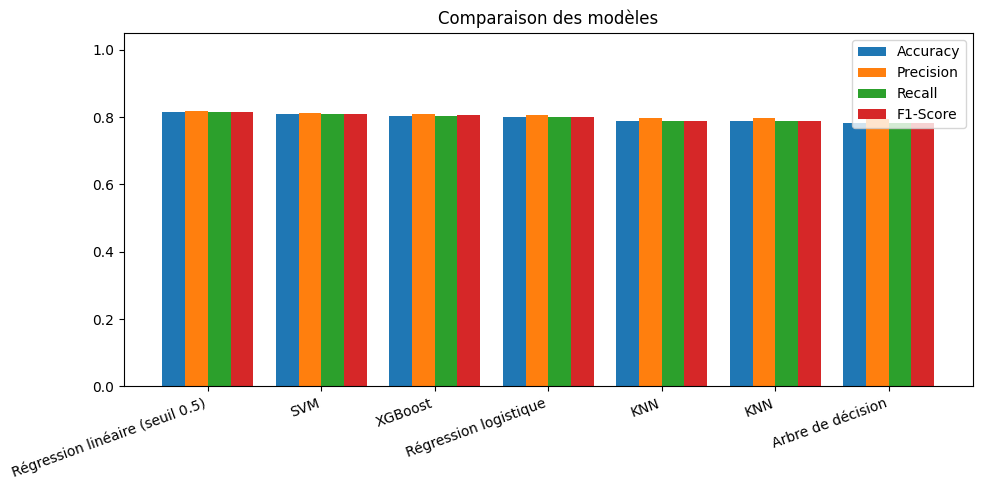

In [71]:
# 5.9 Tableau comparatif de tous les modèles
# FIX: was missing (gap between cell 37 and 39 in original)
resultats_df = pd.DataFrame(resultats).sort_values("F1-Score", ascending=False)
print("\n=== COMPARAISON DES MODÈLES ===")
display(resultats_df.style
        .highlight_max(subset=["Accuracy","Precision","Recall","F1-Score"],
                       color="#c8e6c9")
        .format({c: "{:.3f}" for c in ["Accuracy","Precision","Recall","F1-Score"]})
       )

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(resultats_df))
w = 0.2
for i, metric in enumerate(["Accuracy", "Precision", "Recall", "F1-Score"]):
    ax.bar(x + i*w, resultats_df[metric], w, label=metric)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(resultats_df["Modèle"], rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("Comparaison des modèles")
plt.tight_layout()
plt.show()



=== CROSS VALIDATION 5-FOLD — XGBoost ===
Scores     : [0.836 0.787 0.869 0.803 0.861]
Moyenne    : 0.831
Écart-type : 0.032


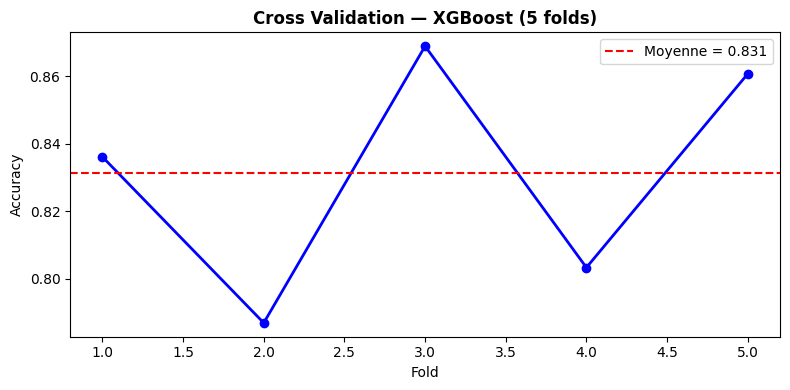

In [72]:
# 5.10 Cross Validation XGBoost (5-fold stratifié)
# Note: CV uses the full resampled data (X_res) for a fair estimate
X_res, y_res = smote.fit_resample(X_train_prep, y_train)  # regenerate for CV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(xgb, X_res, y_res, cv=cv, scoring='accuracy')

print("\n=== CROSS VALIDATION 5-FOLD — XGBoost ===")
print(f"Scores     : {scores_cv.round(3)}")
print(f"Moyenne    : {scores_cv.mean():.3f}")
print(f"Écart-type : {scores_cv.std():.3f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), scores_cv, marker='o', color='blue', linewidth=2)
plt.axhline(y=scores_cv.mean(), color='red', linestyle='--',
            label=f'Moyenne = {scores_cv.mean():.3f}')
plt.title("Cross Validation — XGBoost (5 folds)", fontweight='bold')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


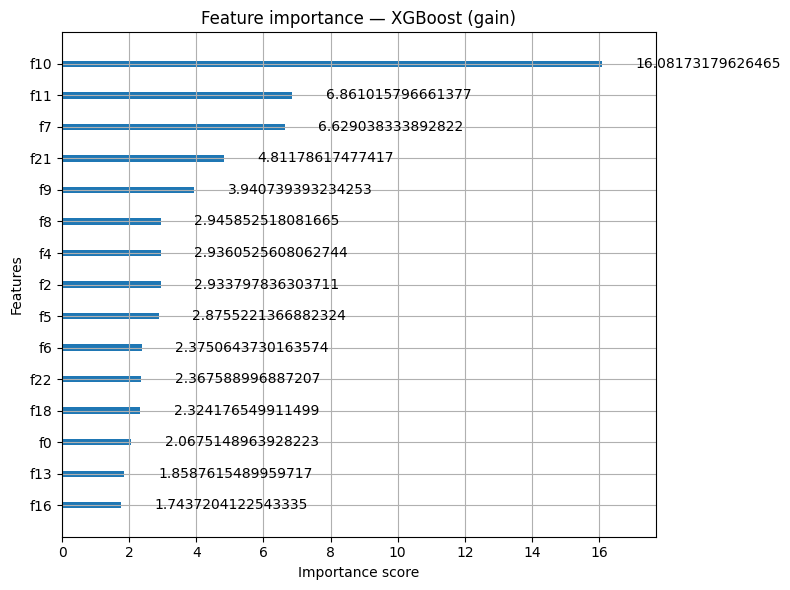

In [73]:
# 5.11 Importance des features (XGBoost)
fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(xgb, ax=ax, max_num_features=15, importance_type="gain")
plt.title("Feature importance — XGBoost (gain)")
plt.tight_layout()
plt.show()


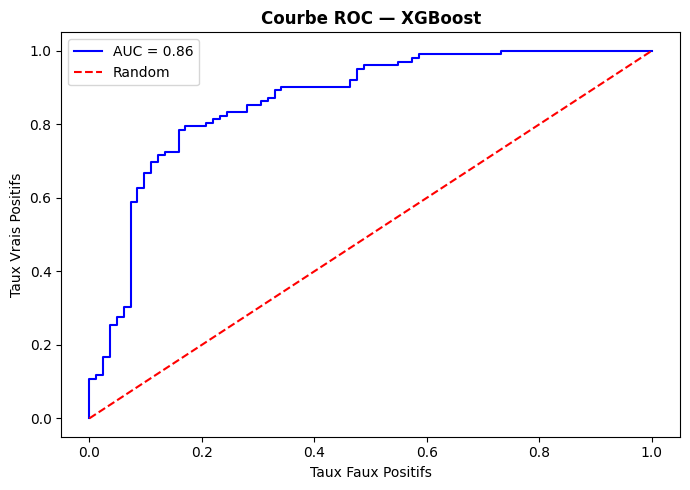


✅ AUC-ROC : 0.86


In [74]:
# 5.12 Courbe ROC — XGBoost
y_prob = xgb.predict_proba(X_test_s)[:, 1]
fpr, tpr, _ = roc_curve(y_test_s, y_prob)
auc = roc_auc_score(y_test_s, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.title("Courbe ROC — XGBoost", fontweight='bold')
plt.xlabel("Taux Faux Positifs")
plt.ylabel("Taux Vrais Positifs")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✅ AUC-ROC : {auc:.2f}")


In [75]:
import joblib, os

export_dir = "exported_models"
os.makedirs(export_dir, exist_ok=True)

joblib.dump(xgb,       os.path.join(export_dir, "xgboost_model.joblib"))
joblib.dump(preprocess, os.path.join(export_dir, "preprocessor.joblib"))

print(f"✅ Modèle exporté      : {export_dir}/xgboost_model.joblib")
print(f"✅ Preprocessor exporté: {export_dir}/preprocessor.joblib")


✅ Modèle exporté      : exported_models/xgboost_model.joblib
✅ Preprocessor exporté: exported_models/preprocessor.joblib
